In [126]:
# importing both datasets from the GitHub repo
import pandas as pd

FBI_data_url = "https://raw.githubusercontent.com/tommytoxic21/Crime_Housing_Data_Analysis/refs/heads/main/FBI_NJ_Crime_Statistics.csv"
US_Census_Bureau_url = "https://raw.githubusercontent.com/tommytoxic21/Crime_Housing_Data_Analysis/refs/heads/main/US_Census_Bureau_Housing_Characteristics.csv"

FBI = pd.read_csv(FBI_data_url)
US_Census_Bureau = pd.read_csv(US_Census_Bureau_url)

In [127]:
# preprocessing and cleaning the data

# removing the first 3 rows and the last row of the FBI dataset as these are unimportant metadata
FBI = FBI.iloc[3:-1]

# setting row 0 to the column headers to get more accurate column titles
FBI.columns = FBI.iloc[0]
FBI = FBI[1:]

# removing \n in FBI columns and the 1 in the "Rape" column
FBI.columns = FBI.columns.str.replace("\n",' ', regex=True)
FBI.columns = FBI.columns.str.replace("1",'', regex=True)

# removing the margin of error and percent columns from the US Census Bureau dataset since a majority of them are negligble
US_Census_Bureau = US_Census_Bureau.loc[:, ~US_Census_Bureau.columns.str.endswith("M")]
US_Census_Bureau = US_Census_Bureau.loc[:, ~US_Census_Bureau.columns.str.endswith("PE")]

# setting row 0 to the column headers to get more accurate column titles rather than numbers
US_Census_Bureau.columns = US_Census_Bureau.iloc[0]
US_Census_Bureau = US_Census_Bureau[1:]

# simplfying column title descriptions to remove anything before "!!"
US_Census_Bureau.columns = US_Census_Bureau.columns.str.split("!!").str[-1]

# remove the last column as it is only NaN
US_Census_Bureau = US_Census_Bureau.iloc[:, :-1]

# renaming duplicate column names
US_Census_Bureau.columns = pd.Series(US_Census_Bureau.columns).where(
    ~pd.Series(US_Census_Bureau.columns).duplicated(),
    pd.Series(US_Census_Bureau.columns) + "_" + pd.Series(US_Census_Bureau.columns).groupby(US_Census_Bureau.columns).cumcount().astype(str)
)

# the Census Bureaus dataset contains a LOT of redundant variables:
# median rooms and precise number of rooms,
# SMOC (bills, taxes, housing expenses, and also mortgage if the resident pays it) and percents for SMOC,
# etc. This leads to a lot of clutter that we can drop from the dataset.
# SMOC also causes a problem for predictions because if we want to predict the value of a home,
# we will not know the SMOC value beforehand. Therefore, we must drop it (median dollars 1 and 2)
# also remove percents from rent
drop_values = [
  "Median (dollars)_1",
  "Median (dollars)_2",
  "Less than $500",
  "$500 to $999",
  "$1,000 to $1,499",
  "$1,500 to $1,999",
  "$2,000 to $2,499",
  "$2,500 to $2,999",
  "$3,000 or more",
  "Less than $250",
  "$250 to $399",
  "$400 to $599",
  "$600 to $799",
  "$800 to $999",
  "$1,000 or more",
  "Less than 20.0 percent",
  "20.0 to 24.9 percent",
  "25.0 to 29.9 percent",
  "30.0 to 34.9 percent",
  "35.0 percent or more",
  "Less than 10.0 percent",
  "10.0 to 14.9 percent",
  "15.0 to 19.9 percent",
  "20.0 to 24.9 percent_1",
  "25.0 to 29.9 percent_1",
  "30.0 to 34.9 percent_1",
  "35.0 percent or more_1",
  "Less than 15.0 percent",
  "15.0 to 19.9 percent_1",
  "20.0 to 24.9 percent_2",
  "25.0 to 29.9 percent_2",
  "30.0 to 34.9 percent_2",
  "35.0 percent or more_2",
  "1 room",
  "2 rooms",
  "3 rooms",
  "4 rooms",
  "5 rooms",
  "6 rooms",
  "7 rooms",
  "8 rooms",
  "9 rooms or more",
  "Not computed",
  "Not computed_1",
  "Not computed_2",
  "No rent paid",
  "Housing units with a mortgage_1",
  "Housing units without a mortgage_1",
  "Housing units with a mortgage (excluding units where SMOCAPI cannot be computed)",
  "Housing unit without a mortgage (excluding units where SMOCAPI cannot be computed)",
  "Total housing units_1",
  "Occupied housing units_1",
  "Owner-occupied units_1",
  "Total housing units_2",
  "Occupied housing units_2",
  "Total housing units_3",
  "Occupied housing units_3",
  "Total housing units_4",
  "Occupied housing units_4",
  "Occupied housing units_5",
  "Occupied housing units_6",
]
US_Census_Bureau = US_Census_Bureau.drop(columns=drop_values)

# removing any area with "CDP" as this will not be found in the FBI dataset
US_Census_Bureau = US_Census_Bureau[~US_Census_Bureau["Geographic Area Name"].str.contains("CDP", case=False, na=False)]

# removing ", New Jersey", " city", " borough"
US_Census_Bureau["Geographic Area Name"] = US_Census_Bureau["Geographic Area Name"].str.replace(", New Jersey",'', regex=True)
US_Census_Bureau["Geographic Area Name"] = US_Census_Bureau["Geographic Area Name"].str.replace(" city",'', regex=True)
US_Census_Bureau["Geographic Area Name"] = US_Census_Bureau["Geographic Area Name"].str.replace(" borough",'', regex=True)

# dropping geography since its useless
US_Census_Bureau = US_Census_Bureau.drop(columns=["Geography"])

# remove certain duplicate columns like total housing units and occupied housing units
delete_duplicates = ['Total housing units', 'Occupied housing units', 'Owner-occupied units', 'Housing units with a mortgage']
mask = US_Census_Bureau.columns.isin(delete_duplicates) & US_Census_Bureau.columns.duplicated()
US_Census_Bureau = US_Census_Bureau.loc[:, ~mask]

In [128]:
# merging the two datasets on city and geographic area name
# note: some towns appear in 1 dataset, but not the other, and vice versa
#       so the data after merging will be smaller
merged_df = pd.merge(FBI, US_Census_Bureau, left_on='City', right_on='Geographic Area Name', how='inner')

# we can now get rid of geographic area name since city == geographic area name for all entries
merged_df = merged_df.drop(columns=['Geographic Area Name'])

# replace missin values with NaN
merged_df = merged_df.replace('-', pd.NA)

# get every column other than city, geographic area name, and geography
cols = merged_df.columns.difference(['City'])

# remove commas and convert the strings to numeric values
for col in cols:
    merged_df[col] = (
        merged_df[col]
        .astype(str)
        .str.replace(',', '', regex=False)
    )
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')

# converting all the crime numbers to rates
# this will give better results because without this, crime is very small compared to
# population, meaning the model may learn that higher population = more crime
rate_df = pd.DataFrame({
    col + "_rate": (merged_df[col] / merged_df["Population"]) * 1000
    for col in FBI.columns[2:]
})
merged_df = pd.concat([merged_df, rate_df], axis=1)

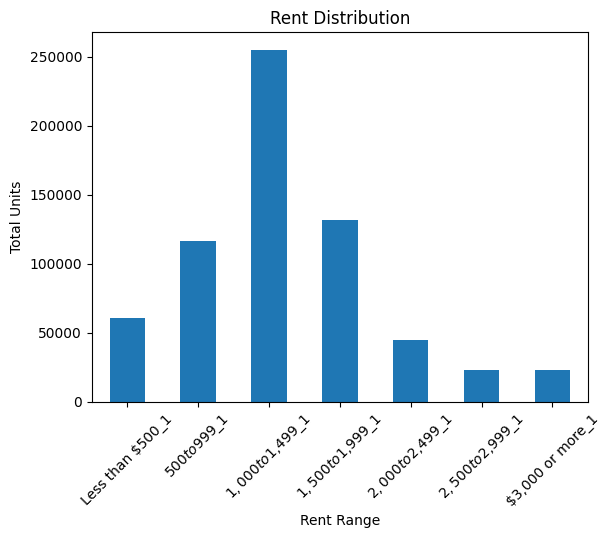

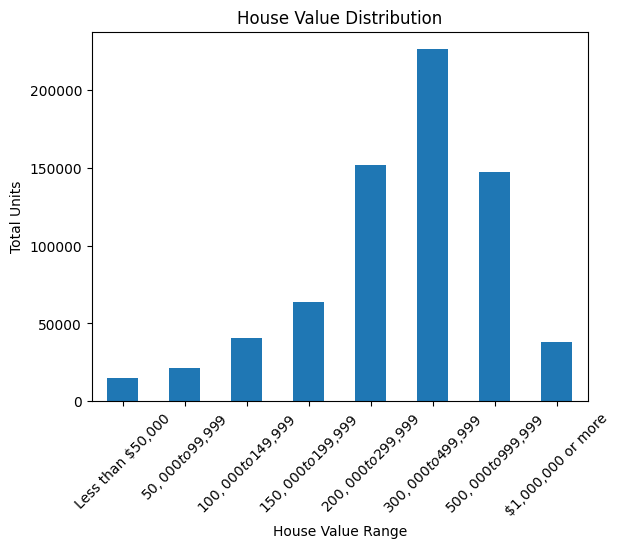

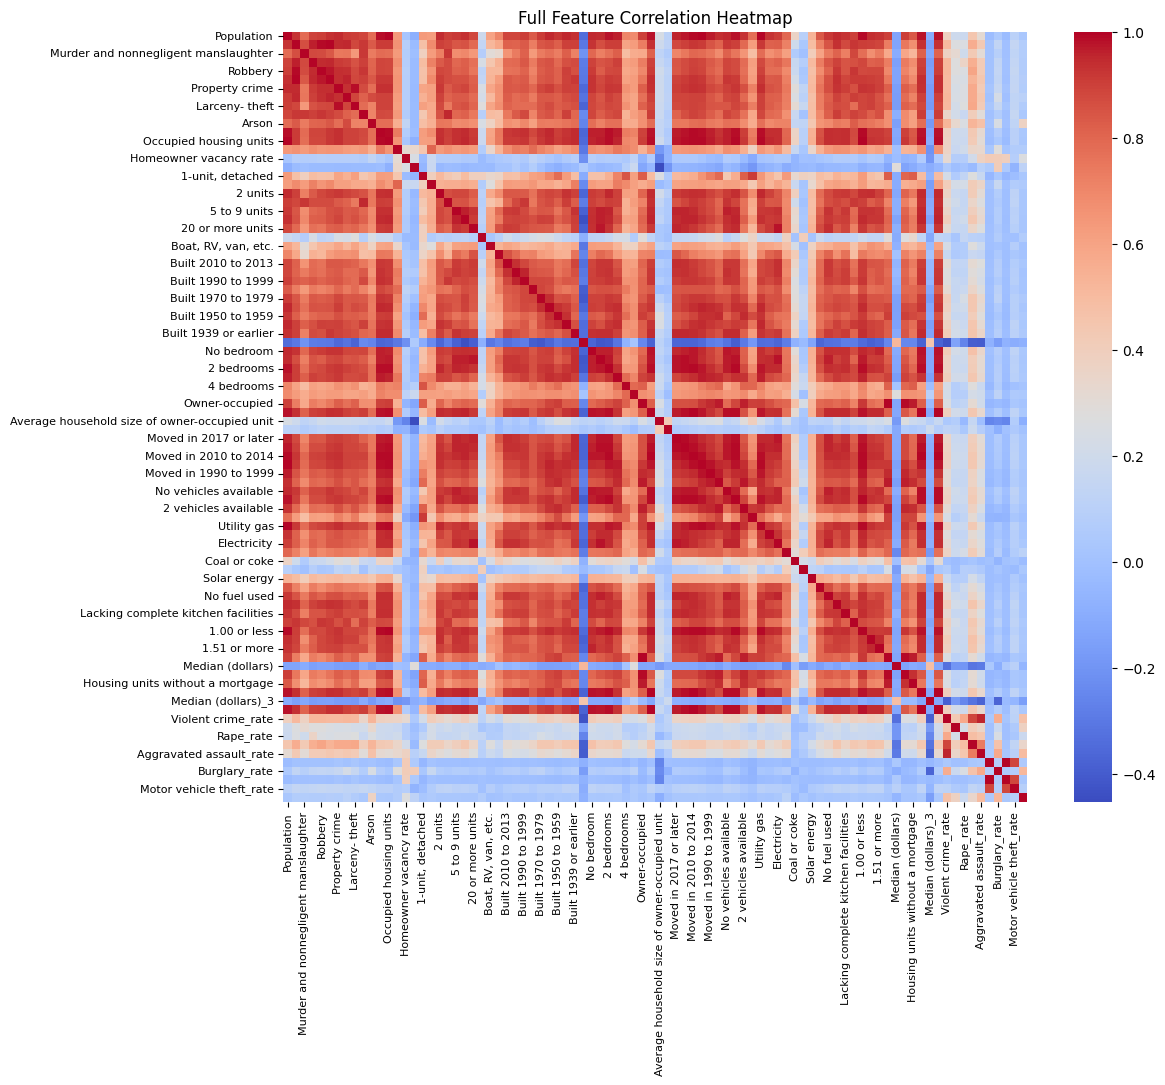

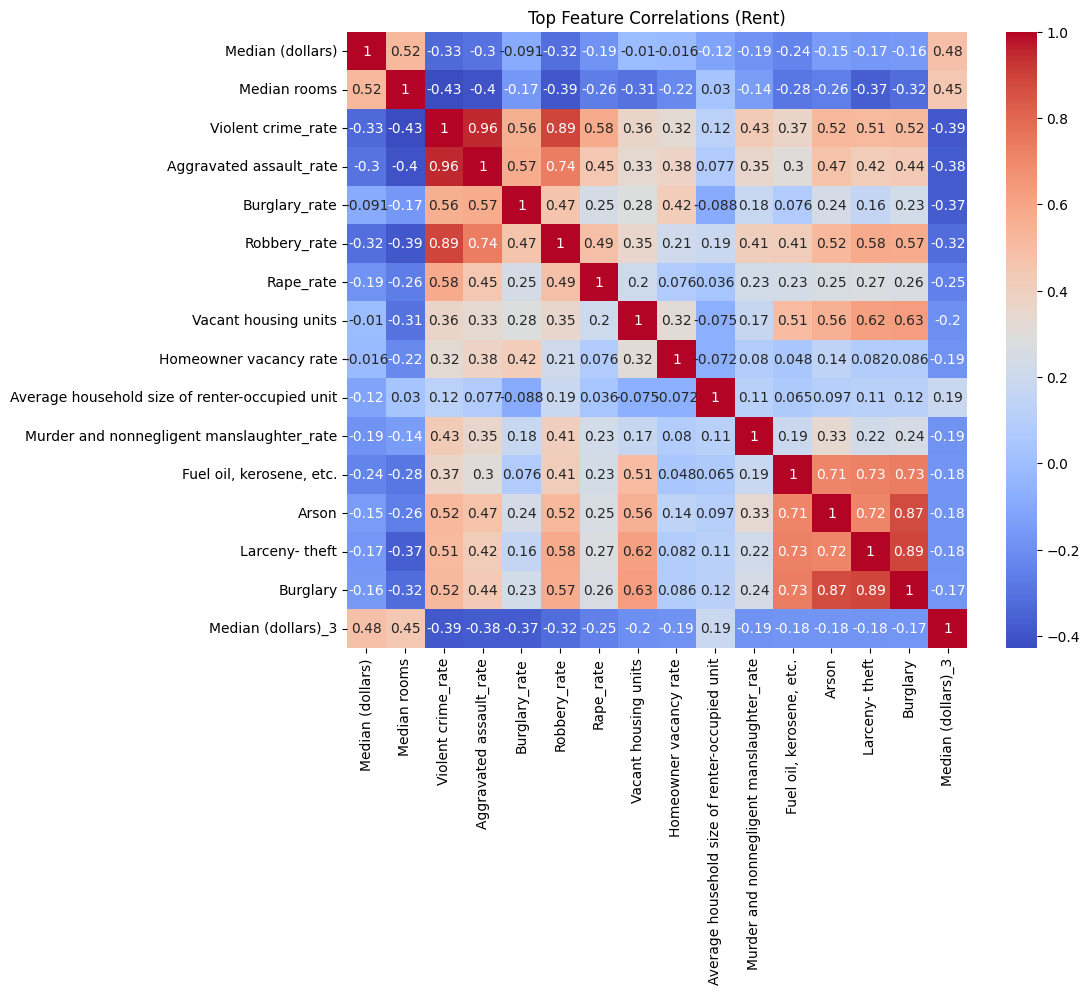

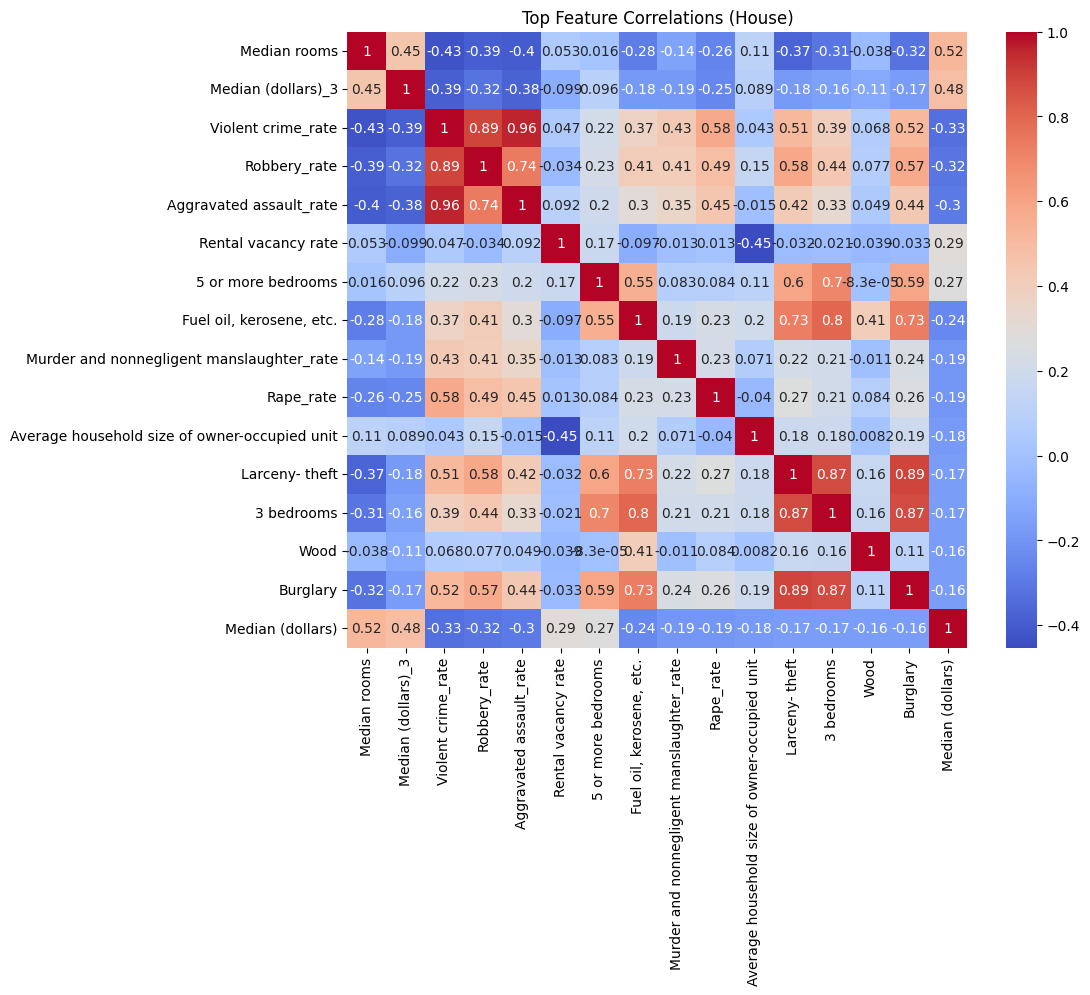

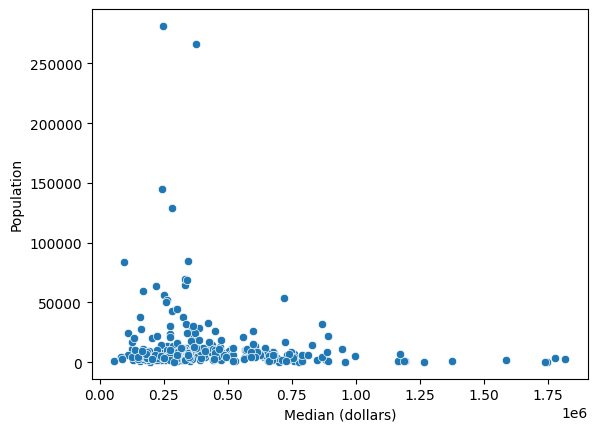

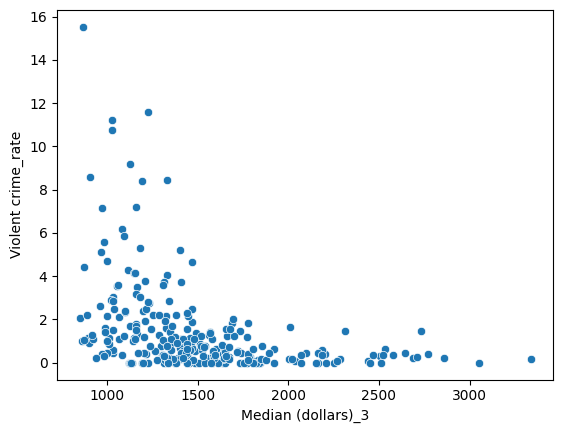

In [129]:
# visualizing data

# histogram
import matplotlib.pyplot as plt
import numpy as np

# gather all columns that have to do with rent prices
rent_cols = [
  "Less than $500_1",
  "$500 to $999_1",
  "$1,000 to $1,499_1",
  "$1,500 to $1,999_1",
  "$2,000 to $2,499_1",
  "$2,500 to $2,999_1",
  "$3,000 or more_1",
]

# gather all columns that have to do with house value
house_cols = [
  "Less than $50,000",
  "$50,000 to $99,999",
  "$100,000 to $149,999",
  "$150,000 to $199,999",
  "$200,000 to $299,999",
  "$300,000 to $499,999",
  "$500,000 to $999,999",
  "$1,000,000 or more",
]

# get the sum for each bin
rent_totals = merged_df[rent_cols].sum()
house_totals = merged_df[house_cols].sum()

# plot rent prices
rent_totals.plot(kind="bar")
plt.title("Rent Distribution")
plt.xlabel("Rent Range")
plt.ylabel("Total Units")
plt.xticks(rotation=45)
plt.show()

# plot house prices
house_totals.plot(kind="bar")
plt.title("House Value Distribution")
plt.xlabel("House Value Range")
plt.ylabel("Total Units")
plt.xticks(rotation=45)
plt.show()

# after preprocessing, the rent prices were found to be right skewed and house prices were found to be
# left skewed. This also means that both target values have some outliers.
# This means that a model would be biased towards the high rent prices which can lead to overestimated rent.
# The model would also be biased towards low house values which can lead to underpriced houses.

# Addtionally, the bins were good to see distributions of the data, but we will remove them
# now for simplicity and reducing dimensions, and instead we will measure median rent and house value
merged_df = merged_df.drop(columns=rent_cols)
merged_df = merged_df.drop(columns=house_cols)

# heat map
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(merged_df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Full Feature Correlation Heatmap")
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

# use the median house value and rent price as target values
target_rent = "Median (dollars)_3"
target_house = "Median (dollars)"

# get the top 15 features which correlate to rent price
corrs_rent = merged_df.corr(numeric_only=True)[target_rent].abs().sort_values(ascending=False)
top_features_rent = corrs_rent[1:16].index

# get a subset
subset_rent = merged_df[top_features_rent.tolist() + [target_rent]]

# show the plot
plt.figure(figsize=(10, 8))
sns.heatmap(subset_rent.corr(), cmap="coolwarm", annot=True)
plt.title("Top Feature Correlations (Rent)")
plt.show()

# do the same for house value
corrs_house = merged_df.corr(numeric_only=True)[target_house].abs().sort_values(ascending=False)
top_features_house = corrs_house[1:16].index

subset_house = merged_df[top_features_house.tolist() + [target_house]]

plt.figure(figsize=(10, 8))
sns.heatmap(subset_house.corr(), cmap="coolwarm", annot=True)
plt.title("Top Feature Correlations (House)")
plt.show()

# As seen in the output, there are 3 heatmaps: 1 for every feature, 1 for the highest correlation
# with median rent price, and 1 for the highest correlation with median home value.
# Due to the immense amount of features, which many are also collinear, we need to reduce how many
# features we actually consider. So, we took the 15 features which correlate the most with
# median rent and median house value. These 15 features are the features we will actually use in testing and modelling.
# For median rent price, the features that correlated most were median house value, median rooms, violent crime rate,
# aggravated assault rate, and more.
# For median house price, the most correlated features were median rooms, average rent price, violent crime rate,
# robbery rate, and more.


# Bivariate analysis
sns.scatterplot(x=merged_df["Median (dollars)"], y=merged_df["Population"])
plt.show()
sns.scatterplot(x=merged_df["Median (dollars)_3"], y=merged_df["Violent crime_rate"])
plt.show()

# As seen in the plots, the correlation between median house value and population can
# be modeled pretty well by a horizontal line, meaning there is little to no correlation.
# The correlation between median rent price and violent crime rate, however, is slightly negative.
# This means that as median rent price goes up, violent crime rate goes slightly down.

In [130]:
# hypothesis testing

# H0: crime statistics and property/neighborhood features do not affect rent prices.
# H1: crime statistics and property/neighborhood features significantly affect rent prices.
# statistical testing
import statsmodels.api as sm

# copy the dataset but exclude any NaN values because they will break the program
# but we can drop them since we will have enough remaining data
merged_no_na = merged_df.copy().dropna()

# copying the most important features from the heatmap creation
X_features_rent = merged_no_na[top_features_rent]

# adding a constant to the X values
X_features_rent = sm.add_constant(X_features_rent)

# copying the target value
y_rent = merged_no_na["Median (dollars)_3"]

model_rent = sm.OLS(y_rent, X_features_rent).fit()
print(model_rent.summary())

# RENT RESULTS
# Important statistics: R^2 = 0.492
#                       Prob (F-statistic) (p value): 1.37e-28
#                       Median (dollars) (P): 0.000
#                       Burglary rate (P): 0.000
#                       Average household size (P): 0.000
# Interpretation:
# An R^2 of ~0.5 shows that the model moderately fits the trends in the data.
# A very low F probability that is < p = 0.05 shows that the model is statistically significant,
# which means we can reject the null hypothesis. Crime rate and property/neighborhood
# features have a statistical significance to rent prices.
# The features which had p < 0.001 shows that they are statistically significant to
# the cost of rent in an area.
# note: we included the average home price in our model which is also statistically significant
# due to its high correlation with rent prices. This may cause data leakage, so
# we will not use this as a primary explanatory factor.


# H0: crime statistics and property/neighborhood features do not affect house value.
# H1: crime statistics and property/neighborhood features significantly affect house value.
# copying the most important features from the heatmap creation
X_features_house = merged_no_na[top_features_house]

# adding a constant to the X values
X_features_house = sm.add_constant(X_features_house)

# copying the target value
y_house = merged_no_na["Median (dollars)"]

model_house = sm.OLS(y_house, X_features_house).fit()
print(model_house.summary())

# HOUSE RESULTS
# Important statistics: R^2 = 0.628
#                       Prob (F-statistic) (p value): 2.10e-44
#                       Median rooms (P): 0.000
#                       Median (dollars)_3 (P): 0.000
#                       5 or more bedrooms (P): 0.000
#                       Average household size (P): 0.000
# Interpretation:
# An R^2 of 0.628 shows that the model fits the trends in the data well.
# The R^2 for houses data was better than the R^2 for rent data which was surprising.
# A very low F probability that is < p = 0.05 shows that the model is statistically significant,
# which means we can reject the null hypothesis. Crime rate and property/neighborhood
# features have a statistical significance to house value.
# However, none of the crime statistics show a statistic significance to house value.
# This could be simply because the other features, like rooms, could be more important.
# So, crime statistics could have an effect on house value, but in this model, they are not statistically significant.
# The features which had p < 0.001 shows that they are statistically significant to
# the value of a house.
# note: we included the average rent price in our model which is also statistically significant
# due to its high correlation with house value. This may cause data leakage, so
# we will not use this as a primary explanatory factor.

                            OLS Regression Results                            
Dep. Variable:     Median (dollars)_3   R-squared:                       0.492
Model:                            OLS   Adj. R-squared:                  0.463
Method:                 Least Squares   F-statistic:                     16.83
Date:                Fri, 01 May 2026   Prob (F-statistic):           1.37e-28
Time:                        20:45:47   Log-Likelihood:                -1841.0
No. Observations:                 258   AIC:                             3712.
Df Residuals:                     243   BIC:                             3765.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

In [131]:
# model training
# we chose random forest because it generalizes better than decision tress
# and can model nonlinear relationships better than linear reg
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# split into train/test
X_train_rent, X_test_rent, y_train_rent, y_test_rent = train_test_split(X_features_rent, y_rent, test_size=0.2, random_state=42)
X_train_house, X_test_house, y_train_house, y_test_house = train_test_split(X_features_house, y_house, test_size=0.2, random_state=42)

# using initial tree sizes for testing
tree_counts = [10, 20, 30, 40, 50, 60, 70, 80]

# creating evaluation metrics
rmse_scores_rent = []
rmse_scores_house = []
r2_scores_rent = []
r2_scores_house = []

# for every tree size, fit the model and get the evaluation metrics
for trees in tree_counts:
  rf_model = RandomForestRegressor(n_estimators=trees, random_state=42)
  rf_rent = rf_model.fit(X_train_rent, y_train_rent)
  y_pred_rent = rf_rent.predict(X_test_rent)
  mse_rent = mean_squared_error(y_test_rent, y_pred_rent)
  rmse_rent = np.sqrt(mse_rent)
  r2_rent = r2_score(y_test_rent, y_pred_rent)
  rmse_scores_rent.append(rmse_rent)
  r2_scores_rent.append(r2_rent)

  rf_house = rf_model.fit(X_train_house, y_train_house)
  y_pred_house = rf_house.predict(X_test_house)
  mse_house = mean_squared_error(y_test_house, y_pred_house)
  rmse_house = np.sqrt(mse_house)
  r2_house = r2_score(y_test_house, y_pred_house)
  rmse_scores_house.append(rmse_house)
  r2_scores_house.append(r2_house)

# show results
results_rent = pd.DataFrame({
    "Number of Trees": tree_counts,
    "RMSE": rmse_scores_rent,
    "R²": r2_scores_rent
})

results_house = pd.DataFrame({
    "Number of Trees": tree_counts,
    "RMSE": rmse_scores_house,
    "R²": r2_scores_house
})

# determine best tree size for rent
best_rmse_rent = 10000
best_tree_count_rent = 50
for i, rmse in enumerate(rmse_scores_rent):
  if rmse < best_rmse_rent:
    best_rmse_rent = rmse
    best_tree_count_rent = tree_counts[i]

# determine best tree size for house
best_rmse_house = 1000000
best_tree_count_house = 50
for i, rmse in enumerate(rmse_scores_house):
  if rmse < best_rmse_house:
    best_rmse_house = rmse
    best_tree_count_house = tree_counts[i]

# trian the best tree size for rent and store the evaluation
final_model_rent = RandomForestRegressor(best_tree_count_rent, random_state=42)
final_model_rent.fit(X_train_rent, y_train_rent)
final_predictions_rent = final_model_rent.predict(X_test_rent)
final_mse_rent = mean_squared_error(y_test_rent, final_predictions_rent)
final_rmse_rent = np.sqrt(final_mse_rent)
final_r2_rent = r2_score(y_test_rent, final_predictions_rent)

# train the best tree size for house value and store the evaluation
final_model_house = RandomForestRegressor(best_tree_count_house, random_state=42)
final_model_house.fit(X_train_house, y_train_house)
final_predictions_house = final_model_house.predict(X_test_house)
final_mse_house = mean_squared_error(y_test_house, final_predictions_house)
final_rmse_house = np.sqrt(final_mse_house)
final_r2_house = r2_score(y_test_house, final_predictions_house)

# print final performance
print("Final Random Forest Model Performance (Rent)")
print("RMSE:", final_rmse_rent)
print("R²:", final_r2_rent)

print("Final Random Forest Model Performance (House)")
print("RMSE:", final_rmse_house)
print("R²:", final_r2_house)

Final Random Forest Model Performance (Rent)
RMSE: 301.79363214772195
R²: 0.45238263811464896
Final Random Forest Model Performance (House)
RMSE: 125273.18648273645
R²: 0.5780836649747607


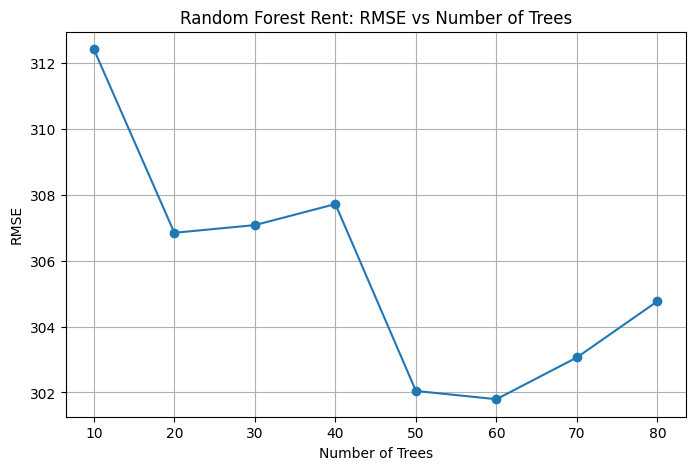

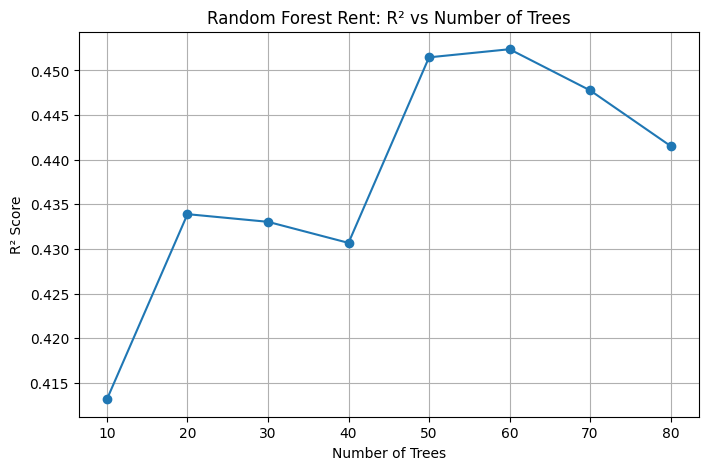

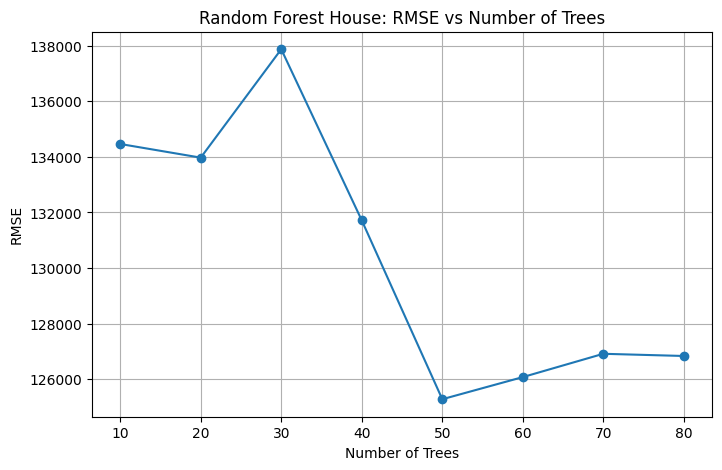

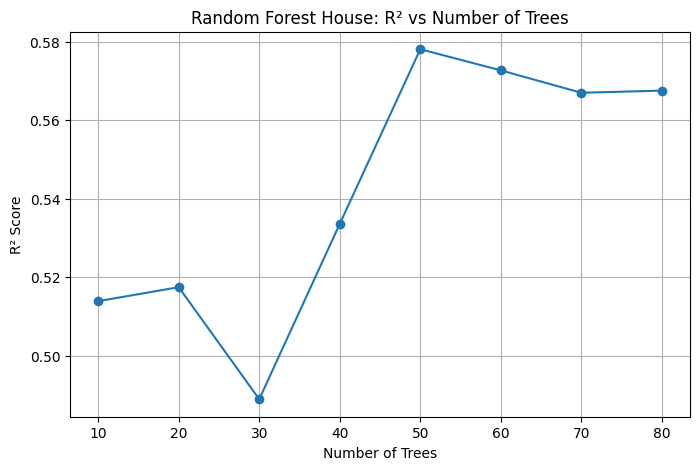

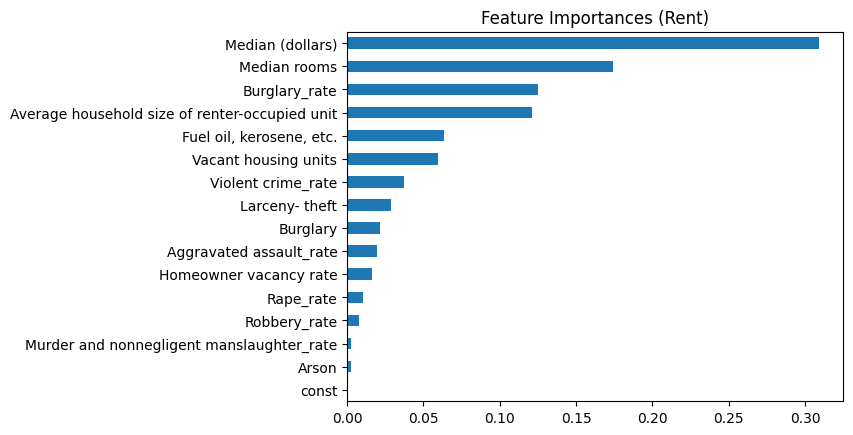

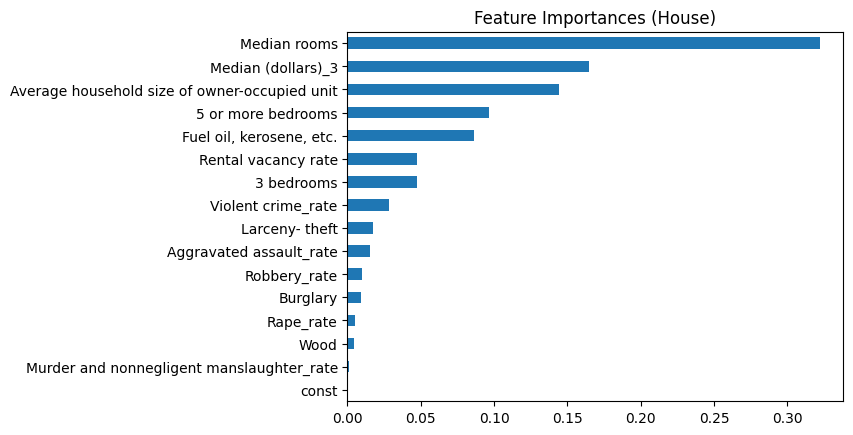

In [132]:
# graphs of results for each model

# graph rmse and r^2
plt.figure(figsize=(8, 5))
plt.plot(tree_counts, rmse_scores_rent, marker="o")
plt.title("Random Forest Rent: RMSE vs Number of Trees")
plt.xlabel("Number of Trees")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()
plt.figure(figsize=(8, 5))
plt.plot(tree_counts, r2_scores_rent, marker="o")
plt.title("Random Forest Rent: R² vs Number of Trees")
plt.xlabel("Number of Trees")
plt.ylabel("R² Score")
plt.grid(True)
plt.show()
plt.figure(figsize=(8, 5))
plt.plot(tree_counts, rmse_scores_house, marker="o")
plt.title("Random Forest House: RMSE vs Number of Trees")
plt.xlabel("Number of Trees")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()
plt.figure(figsize=(8, 5))
plt.plot(tree_counts, r2_scores_house, marker="o")
plt.title("Random Forest House: R² vs Number of Trees")
plt.xlabel("Number of Trees")
plt.ylabel("R² Score")
plt.grid(True)
plt.show()

# we also wanted to see the importances of each features in the forest
importances_rent = final_model_rent.feature_importances_
column_names_rent = X_features_rent.columns
feature_importance_rent = pd.Series(importances_rent, index=column_names_rent)
feature_importance_rent = feature_importance_rent.sort_values(ascending=False)

importances_house = final_model_house.feature_importances_
column_names_house = X_features_house.columns
feature_importance_house = pd.Series(importances_house, index=column_names_house)
feature_importance_house = feature_importance_house.sort_values(ascending=False)

# plot the feature importance
feature_importance_rent.plot(kind='barh')
plt.title("Feature Importances (Rent)")
plt.gca().invert_yaxis()
plt.show()

feature_importance_house.plot(kind='barh')
plt.title("Feature Importances (House)")
plt.gca().invert_yaxis()
plt.show()

In [133]:
# knowledge discovery

# Throughout the life cycle of this project, we discovered many interesting things about the data we collected.
# The first obvious observation was that median rooms was the most important feature for
# both prices, aside from median house price which we are ignoring. This was not surprising.
# However, what we found interesting was the differences between how crime affects house value and rent prices.
# For rent prices, the burglary rate is the most important feature following median rooms.
# For house value, however, violent crime rate is the 7th most important feature that determines house value.
# So, not only did we find out that different crimes affect house value and rent differently,
# but that rent prices are overall more prone to correlate with crime statistics.
# For example, in the feature importance graph of house value,
# there are a few features of the house itself that are more important that crime stats.
# Even when the crime stats do show up, the bar is relatively small meaning its overall
# importance is not that significant in determining house value.
# On the other hand, in the rent feature importance graph, there are more crime stats present,
# AND they also have larger values that the house graph.
# Another thing we found that was interesting was the importance of the average household size.
# This may be a collinearity issue because the underlying reason for this importance may be that,
# as the average household size increases, property sizes are larger in that area, and larger
# properties are obviously more expensive. So, that could explain the significance of household size.
# The last thing we found interesting was the importance of fuel oil, kersone, etc. as the heating source for the property.
# This could either be another underlying issue, or simply that oil heating is more expensive than
# other methods, therefore driving up prices.
# One last thing we wanted to mention was that, just because crime and property values have correlation,
# does not mean that increased crime causes decreased property value.
# There could be other underlying causation, such as difference in income, fewer resources, or others
# which may cause this discrepency.
# So, as an actionable insight: improving safety in a neighborhood can result in a more
# desirable area and increased property values.